In [10]:

import sys

import pandas as pd
from sqlalchemy import create_engine
from sqlalchemy import text, bindparam

from nhs_waiting_lists.utils.proj_paths import find_project_root

project_root = find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [11]:

from nhs_waiting_lists.constants import proj_db_path

DB_PATH = project_root / proj_db_path / "data/nhs_provider_data.db"
DATA_DIR = "./data"

# conn = sqlite3.connect(DB_PATH)

conn = create_engine(f"sqlite:///{DB_PATH}")

In [12]:
PROVIDER_CODES = ["RTF", "RWF", "RTE", "REF", "RWH", "R0B", "RVJ", "RHW", "RDU", "RH8", "RWY", "RXC", "RL4", "RDE",
                  "RXK", "RXR", "RJ2", "RN5", "RHU", "RGN", "RWP", "RWD", "RAJ", "A4M8P"]
TREATMENT_CODES = ('C_101', 'C_110', 'C_320', 'C_330', 'C_400', 'C_502', 'C_301', 'C_100', 'C_101', 'C_110', 'C_120',
                   'C_130', 'C_140', 'C_150', 'C_160', 'C_170', 'C_300', 'C_301', 'C_320', 'C_330', 'C_340', 'C_400',
                   'C_410', 'C_430', 'C_502')

In [13]:


query = text("""
             SELECT i.period,
                    i.provider_code                                                                      as provider,
                    i.treatment_function_code                                                            as treatment_code,
                    i.treatment_function                                                                 as treatment,
                    i.Total_number_of_incomplete_pathways                                                as incomplete,
                    LAG(i.Total_number_of_incomplete_pathways) OVER (
                        PARTITION BY i.provider_code, i.treatment_function_code
                        ORDER BY i.period)                                                               AS inc_prev,

                    i.Total_number_of_incomplete_pathways - LAG(i.Total_number_of_incomplete_pathways) OVER (
                        PARTITION BY i.provider_code, i.treatment_function_code
                        ORDER BY i.period)                                                               AS inc_diff,
                    (i.Total_number_of_incomplete_pathways /
                     LAG(i.Total_number_of_incomplete_pathways) OVER (
                         PARTITION BY i.provider_code, i.treatment_function_code
                         ORDER BY i.period
                         ) - 1)                                                                          AS frac_change,
                    -- dta.Total_number_of_incomplete_pathways_with_a_decision_to_admit_for_treatment as incomplete_dta,
                    a.Total_number_of_completed_pathways_with_a_known_clock_start                        as admitted,
                    LAG(a.Total_number_of_completed_pathways_with_a_known_clock_start)
                        OVER (PARTITION BY i.provider_code, i.treatment_function_code ORDER BY i.period) as admitted_prev,
                    na.Total_number_of_completed_pathways_with_a_known_clock_start                       as nonadmitted,
                    LAG(na.Total_number_of_completed_pathways_with_a_known_clock_start)
                        OVER (PARTITION BY i.provider_code, i.treatment_function_code ORDER BY i.period) as nonadmitted_prev,
                    np.Number_of_new_RTT_clock_starts_during_the_month                                   as new_periods,
                    LAG(np.Number_of_new_RTT_clock_starts_during_the_month)
                        OVER (PARTITION BY i.provider_code, i.treatment_function_code ORDER BY i.period) as new_periods_prev,
                    -- the accunting identity
                    (
                        i.Total_number_of_incomplete_pathways
                            - (
                            LAG(i.Total_number_of_incomplete_pathways)
                                OVER (PARTITION BY i.provider_code, i.treatment_function_code ORDER BY i.period)
                                + np.Number_of_new_RTT_clock_starts_during_the_month
                                - a.Total_number_of_completed_pathways_with_a_known_clock_start
                                - na.Total_number_of_completed_pathways_with_a_known_clock_start
                            )
                        )                                                                                AS residual,
                    np.Number_of_new_RTT_clock_starts_during_the_month
                        - a.Total_number_of_completed_pathways_with_a_known_clock_start
                        - na.Total_number_of_completed_pathways_with_a_known_clock_start
                                                                                                         AS delta
             FROM incomplete AS i
                      INNER JOIN incomplete_with_dta AS dta ON i.period = dta.period
                 AND i.provider_code = dta.provider_code
                 AND i.treatment_function_code = dta.treatment_function_code
                      INNER JOIN new_periods np ON i.period = np.period
                 AND i.provider_code = np.provider_code
                 AND i.treatment_function_code = np.treatment_function_code
                      INNER JOIN admitted a ON i.period = a.period
                 AND i.provider_code = a.provider_code
                 AND i.treatment_function_code = a.treatment_function_code
                      INNER JOIN nonadmitted na ON i.period = na.period
                 AND i.provider_code = na.provider_code
                 AND i.treatment_function_code = na.treatment_function_code
                      INNER JOIN provider ON i.provider_code = provider.Trust_code
             WHERE i.provider_code IN :provider_codes
               AND treatment_code IN :treatment_codes
               AND provider.Trust_subtype = 'Acute - Large'
             ORDER BY provider ASC, treatment_code ASC, i.period ASC; \
             """).bindparams(
    bindparam('provider_codes', expanding=True),
    bindparam('treatment_codes', expanding=True)
)

df = pd.read_sql(query, conn, params={
    'provider_codes': PROVIDER_CODES,
    'treatment_codes': TREATMENT_CODES}
                 )  # type: ignore[arg-type]
df = df.assign(
    inc_diff=df["incomplete"] - df["inc_prev"],
)
df = df.assign(
    residual_check_diff=df['inc_diff'] - df['delta']
)
df = df.assign(
    residual_check=(df['residual'] - df['residual_check_diff']).abs().max()
)



In [17]:
df.query("provider == 'A4M8P' and treatment_code == 'C_160'")

,period,provider,treatment_code,treatment,incomplete,inc_prev,inc_diff,frac_change,admitted,admitted_prev,nonadmitted,nonadmitted_prev,new_periods,new_periods_prev,residual,delta,residual_check_diff,residual_check


In [4]:
df.query('provider == "R0B" and treatment_code == "C_110"')[
    [
        "period", "incomplete", "inc_prev", "inc_diff", "residual", "delta", "residual_check"
    ]
]

,period,incomplete,inc_prev,inc_diff,residual,delta,residual_check
154,2019-04-01,3981.0,NaN,NaN,NaN,148.0,0.0
155,2019-05-01,4008.0,3981.0,27.0,-187.0,214.0,0.0
156,2019-06-01,3881.0,4008.0,-127.0,-187.0,60.0,0.0
157,2019-07-01,3806.0,3881.0,-75.0,-165.0,90.0,0.0
158,2019-08-01,3714.0,3806.0,-92.0,-227.0,135.0,0.0
...,...,...,...,...,...,...,...
226,2025-04-01,7683.0,7560.0,123.0,-240.0,363.0,0.0
227,2025-05-01,7610.0,7683.0,-73.0,-172.0,99.0,0.0
228,2025-06-01,7884.0,7610.0,274.0,-113.0,387.0,0.0
229,2025-07-01,7876.0,7884.0,-8.0,-252.0,244.0,0.0


In [274]:
from plotnine import (
    scale_x_datetime
)
import pandas as pd

df2 = df.query('provider == "R0B" and treatment_code == "C_301"')[
    [
        "period",
        "incomplete",
        "inc_prev",
        "inc_diff",
        "residual",
        "admitted",
        "nonadmitted",
        "new_periods",
        "delta",
    ]
]

df2

,period,incomplete,inc_prev,inc_diff,residual,admitted,nonadmitted,new_periods,delta
770,2019-04-01,1043.0,NaN,NaN,NaN,230.0,299.0,635.0,106.0
771,2019-05-01,1146.0,1043.0,103.0,-66.0,254.0,282.0,705.0,169.0
772,2019-06-01,1156.0,1146.0,10.0,-57.0,310.0,302.0,679.0,67.0
773,2019-07-01,1247.0,1156.0,91.0,-58.0,256.0,425.0,830.0,149.0
774,2019-08-01,1248.0,1247.0,1.0,-110.0,322.0,357.0,790.0,111.0
...,...,...,...,...,...,...,...,...,...
842,2025-04-01,1178.0,1234.0,-56.0,-89.0,289.0,704.0,1026.0,33.0
843,2025-05-01,1123.0,1178.0,-55.0,-84.0,223.0,709.0,961.0,29.0
844,2025-06-01,1089.0,1123.0,-34.0,-121.0,212.0,684.0,983.0,87.0
845,2025-07-01,1125.0,1089.0,36.0,-101.0,240.0,712.0,1089.0,137.0


In [275]:

child_long = df2.reset_index().melt(
    id_vars=['period'],
    value_vars=['residual', 'delta', 'inc_diff', 'new_periods', 'nonadmitted', 'admitted'],
    var_name='metric',
    value_name='value'
)

child_long

,period,metric,value
0,2019-04-01,residual,NaN
1,2019-05-01,residual,-66.0
2,2019-06-01,residual,-57.0
3,2019-07-01,residual,-58.0
4,2019-08-01,residual,-110.0
...,...,...,...
457,2025-04-01,admitted,289.0
458,2025-05-01,admitted,223.0
459,2025-06-01,admitted,212.0
460,2025-07-01,admitted,240.0


/home/tomhodder/Sync/projects/data/nhs_england_data/.venv/lib/python3.13/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_col : Removed 2 rows containing missing values.


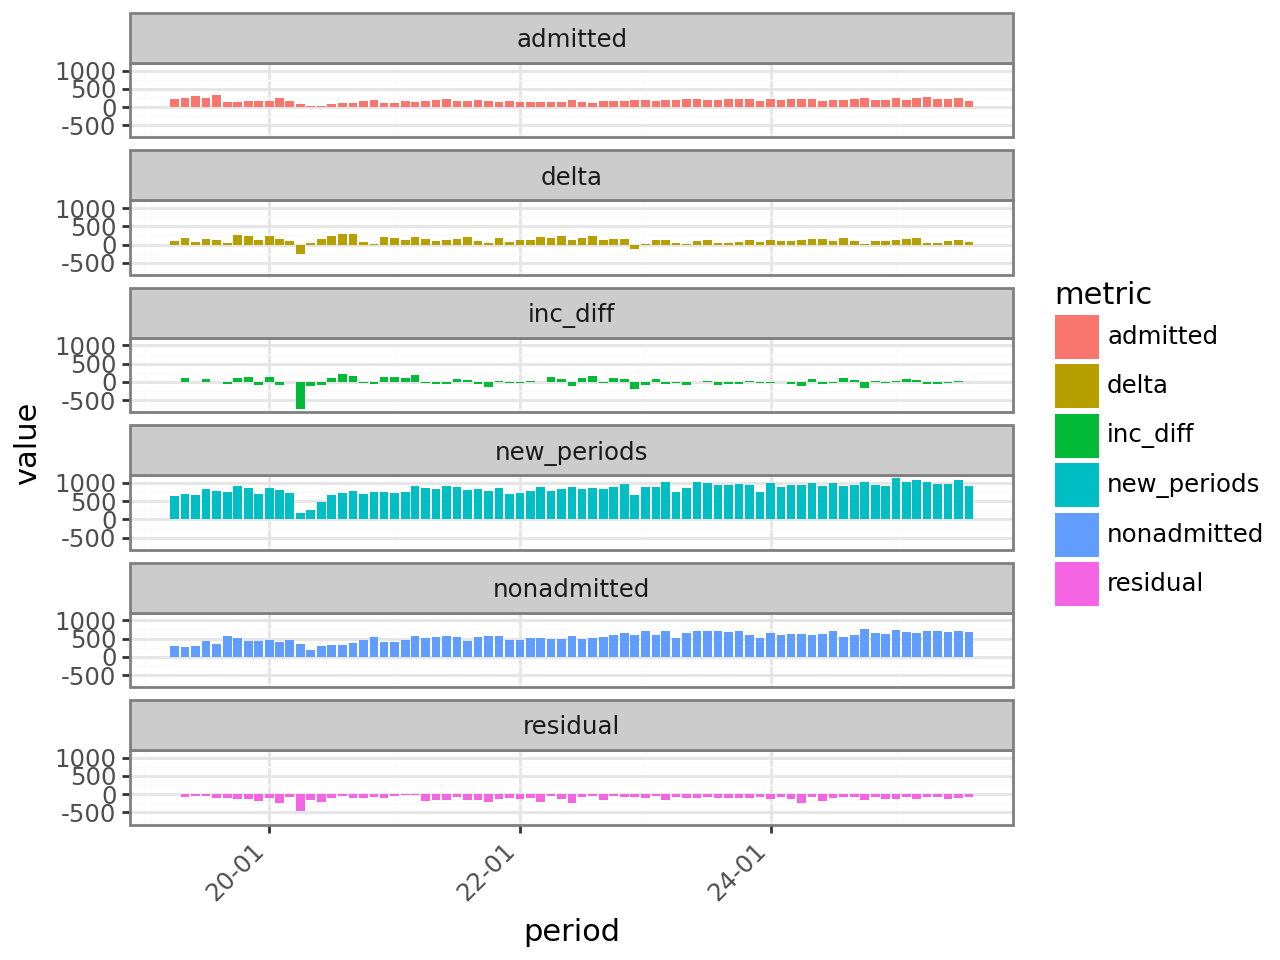

In [276]:
from plotnine import ggplot, aes, geom_line, geom_col, facet_wrap, theme_bw, theme, element_text

p = (
        ggplot(child_long, aes(x="period", y="value", fill="metric"))
        + scale_x_datetime(date_labels="%y-%m")
        + geom_col(position="dodge")  # side-by-side bars
        + facet_wrap("~metric", ncol=1)
        + theme_bw()
        + theme(axis_text_x=element_text(rotation=45, hjust=1))
)
p



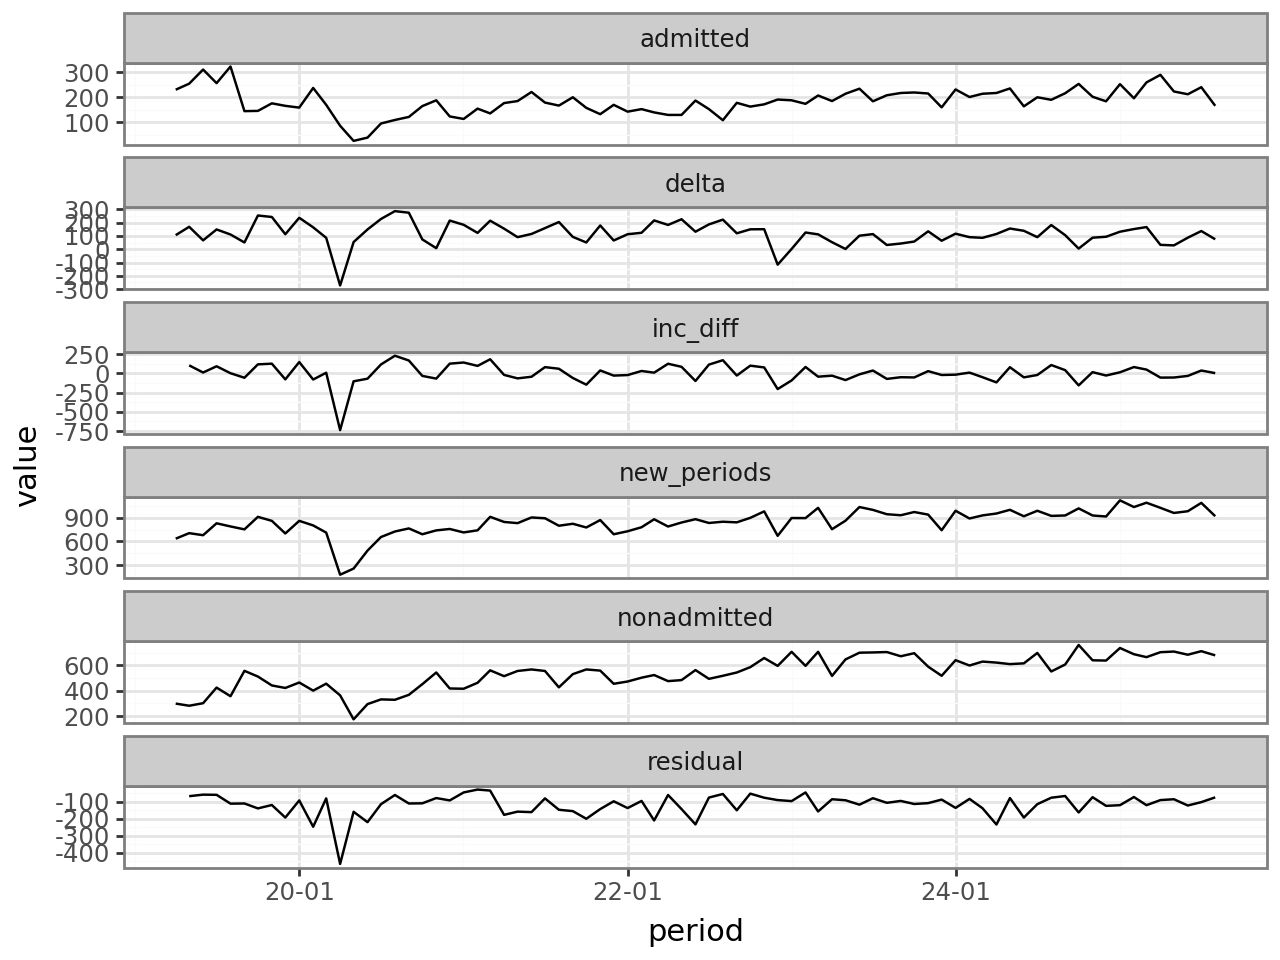

In [277]:
p = (
        ggplot(child_long, aes(x="period", y="value", group=1))
        + scale_x_datetime(date_labels="%y-%m")
        + geom_line()
        + facet_wrap("~metric", ncol=1, scales="free_y")  # or ncol=2 for side-by-side
        + theme_bw()
)
p

/home/tomhodder/Sync/projects/data/nhs_england_data/.venv/lib/python3.13/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_col : Removed 2 rows containing missing values.


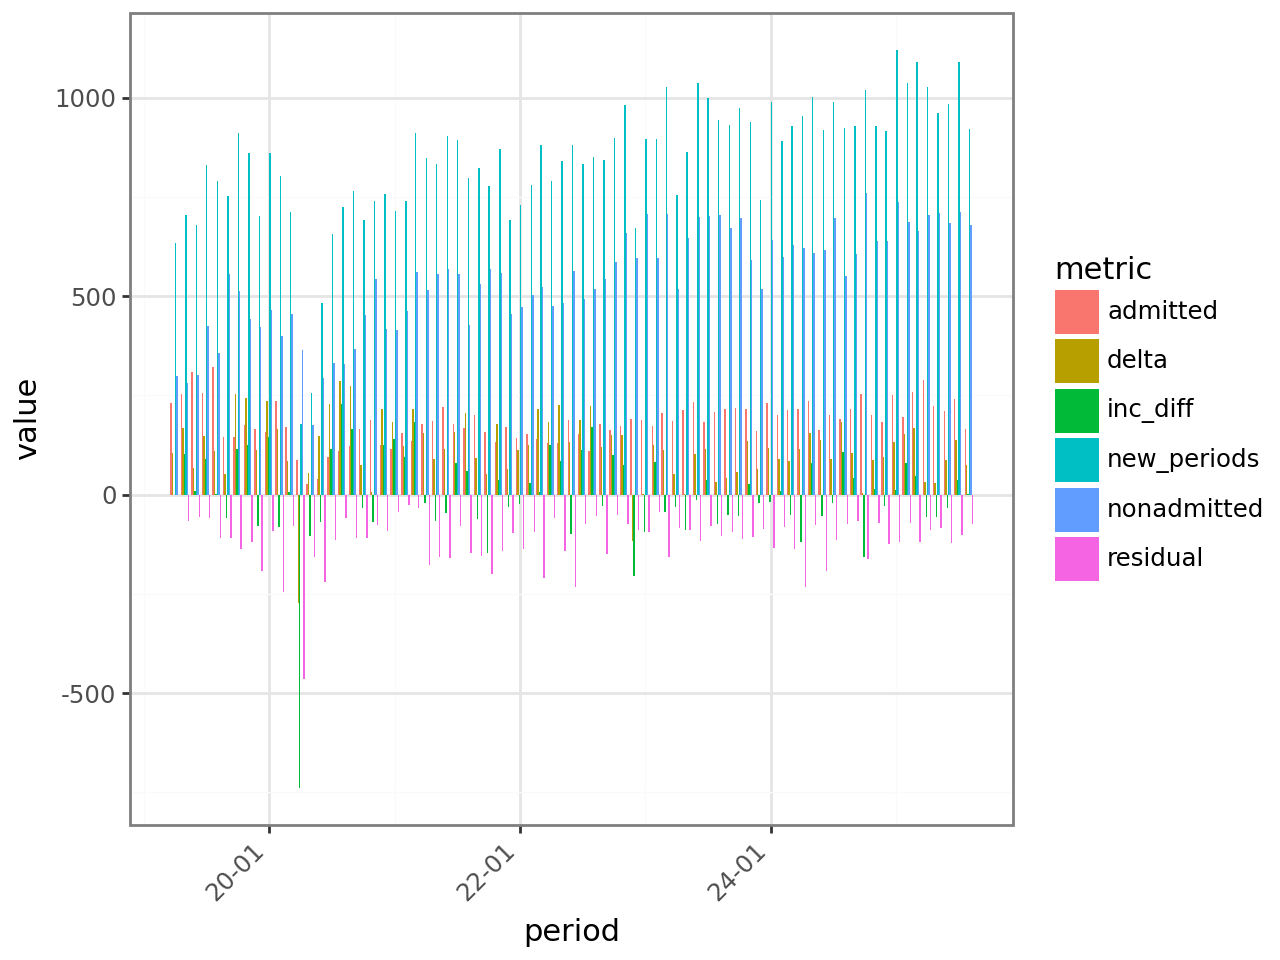

In [278]:
p = (
        ggplot(child_long, aes(x="period", y="value", fill="metric"))
        + scale_x_datetime(date_labels="%y-%m")
        + geom_col(position="dodge")  # or position="stack" for stacked
        + theme_bw()
        + theme(axis_text_x=element_text(rotation=45, hjust=1))
)
p

In [279]:
returns_wide = (
    df.query("treatment_code == 'C_101'")
    .pivot(
        index="period",
        columns="provider",
        values="frac_change"
    )
    .reset_index()
)

returns_wide

provider,period,R0B,RAJ,RDE,RDU,REF,RGN,RH8,RHU,RHW,...,RTF,RVJ,RWD,RWF,RWH,RWP,RWY,RXC,RXK,RXR
0,2019-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-02-01,NaN,0.028679,0.052955,0.000000,-0.072455,0.021695,0.035657,0.054479,-0.119658,...,0.099582,0.001005,0.014895,-0.014112,0.145679,0.009619,0.046078,-0.056781,-0.026420,-0.016718
2,2019-03-01,NaN,0.025594,0.026718,-0.062969,-0.041317,0.010617,0.009764,-0.081967,-0.090615,...,0.026599,-0.019322,0.065847,-0.040967,-0.065194,-0.008213,-0.016256,-0.016949,-0.020353,-0.017632
3,2019-04-01,NaN,0.021390,0.043954,0.072400,0.016835,-0.036187,0.015776,0.028680,0.046263,...,0.117829,0.031986,-0.020097,-0.065878,0.107781,0.004969,-0.068763,0.087396,-0.000693,0.077564
4,2019-05-01,-0.054006,0.174520,0.023251,-0.005968,-0.017219,0.001211,-0.042585,0.027354,0.022676,...,-0.033113,0.055046,-0.020129,-0.032507,0.055671,-0.046803,-0.021752,-0.026244,-0.052668,-0.067817
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,2025-04-01,-0.019841,-0.020139,-0.034176,-0.013164,-0.006393,-0.084497,0.025736,-0.015937,0.004555,...,-0.056425,0.020935,-0.039809,-0.027539,-0.058646,-0.051566,-0.002316,0.040404,-0.044122,0.011490
76,2025-05-01,0.003873,0.004524,-0.011444,0.025548,0.007507,-0.051730,-0.023881,-0.203475,-0.012778,...,-0.141515,-0.062884,-0.004717,-0.012872,-0.029088,-0.020220,-0.008706,-0.005049,-0.035931,-0.062145
77,2025-06-01,0.009995,-0.015859,-0.017033,-0.029541,-0.053220,0.069474,-0.001858,-0.039926,-0.023800,...,0.013494,-0.010066,-0.038663,0.018629,-0.053786,-0.051594,0.017564,-0.003318,-0.004014,0.042038
78,2025-07-01,0.043576,0.020889,-0.035738,-0.049750,-0.059584,0.013333,0.025132,-0.070851,0.004705,...,-0.045700,-0.013410,-0.029061,0.040600,-0.002742,0.024662,-0.045455,0.011357,-0.002591,-0.046838


In [280]:
sigma = (
    returns_wide
    .drop(columns=["period"])
    .corr()
)
sigma

provider,R0B,RAJ,RDE,RDU,REF,RGN,RH8,RHU,RHW,RJ2,...,RTF,RVJ,RWD,RWF,RWH,RWP,RWY,RXC,RXK,RXR
provider,,,,,,,,,,,,,,,,,,,,,
R0B,1.000000,-0.637202,0.248014,0.170029,-0.003637,0.327133,0.080662,0.061610,0.286104,0.215733,...,0.414668,0.212743,0.359891,0.052138,0.128005,0.173885,0.458389,0.368520,0.428557,0.328460
RAJ,-0.637202,1.000000,-0.140909,-0.049734,-0.014926,-0.097023,-0.033629,0.030854,-0.053689,-0.216999,...,-0.395447,-0.024422,-0.143020,0.151898,-0.162914,-0.013249,-0.413232,-0.355233,-0.183732,-0.237437
RDE,0.248014,-0.140909,1.000000,0.034973,0.154843,-0.018107,0.171172,0.212708,0.085429,0.035884,...,0.256688,0.151971,0.062326,-0.002859,0.175538,0.000208,0.089510,0.082562,-0.001294,0.091151
RDU,0.170029,-0.049734,0.034973,1.000000,-0.016433,-0.054372,-0.015185,0.021646,-0.016254,0.226923,...,0.066054,-0.047991,0.065776,-0.052936,-0.101896,0.069257,0.104845,-0.038520,0.114738,0.164663
REF,-0.003637,-0.014926,0.154843,-0.016433,1.000000,-0.015348,-0.112772,0.062487,0.023553,0.013787,...,0.041849,-0.006846,-0.139183,0.207759,0.073787,0.064012,-0.025778,-0.027470,-0.001958,0.035566
RGN,0.327133,-0.097023,-0.018107,-0.054372,-0.015348,1.000000,0.010318,0.061775,0.015467,-0.002213,...,0.316018,0.123505,0.046721,0.240426,-0.047638,0.093026,0.328152,-0.109339,0.259470,0.146036
RH8,0.080662,-0.033629,0.171172,-0.015185,-0.112772,0.010318,1.000000,0.018981,-0.048142,-0.033175,...,-0.052890,0.158808,-0.238305,-0.016633,0.124587,0.050774,0.073605,0.287886,0.118590,0.110796
RHU,0.061610,0.030854,0.212708,0.021646,0.062487,0.061775,0.018981,1.000000,-0.222302,0.063329,...,0.187938,0.216641,0.090303,0.012537,0.010567,-0.066772,-0.161048,0.302642,0.032020,0.011522
RHW,0.286104,-0.053689,0.085429,-0.016254,0.023553,0.015467,-0.048142,-0.222302,1.000000,0.056605,...,0.161248,0.038232,0.309921,0.124003,-0.083455,0.232280,0.033713,0.033461,0.197690,0.161767


In [281]:
from plotnine import *
from mizani.formatters import percent_format

sigma_long = (sigma
.reset_index()
.melt(
    id_vars="provider",
    var_name="symbol_b",
    value_name="value"
)
)
sigma_long["symbol_b"] = pd.Categorical(
    sigma_long["symbol_b"],
    categories=sigma_long["symbol_b"].unique()[::-1],
    ordered=True
)
sigma_long

,provider,symbol_b,value
0,R0B,R0B,1.000000
1,RAJ,R0B,-0.637202
2,RDE,R0B,0.248014
3,RDU,R0B,0.170029
4,REF,R0B,-0.003637
...,...,...,...
524,RWP,RXR,0.113793
525,RWY,RXR,0.201467
526,RXC,RXR,0.088094
527,RXK,RXR,0.259708


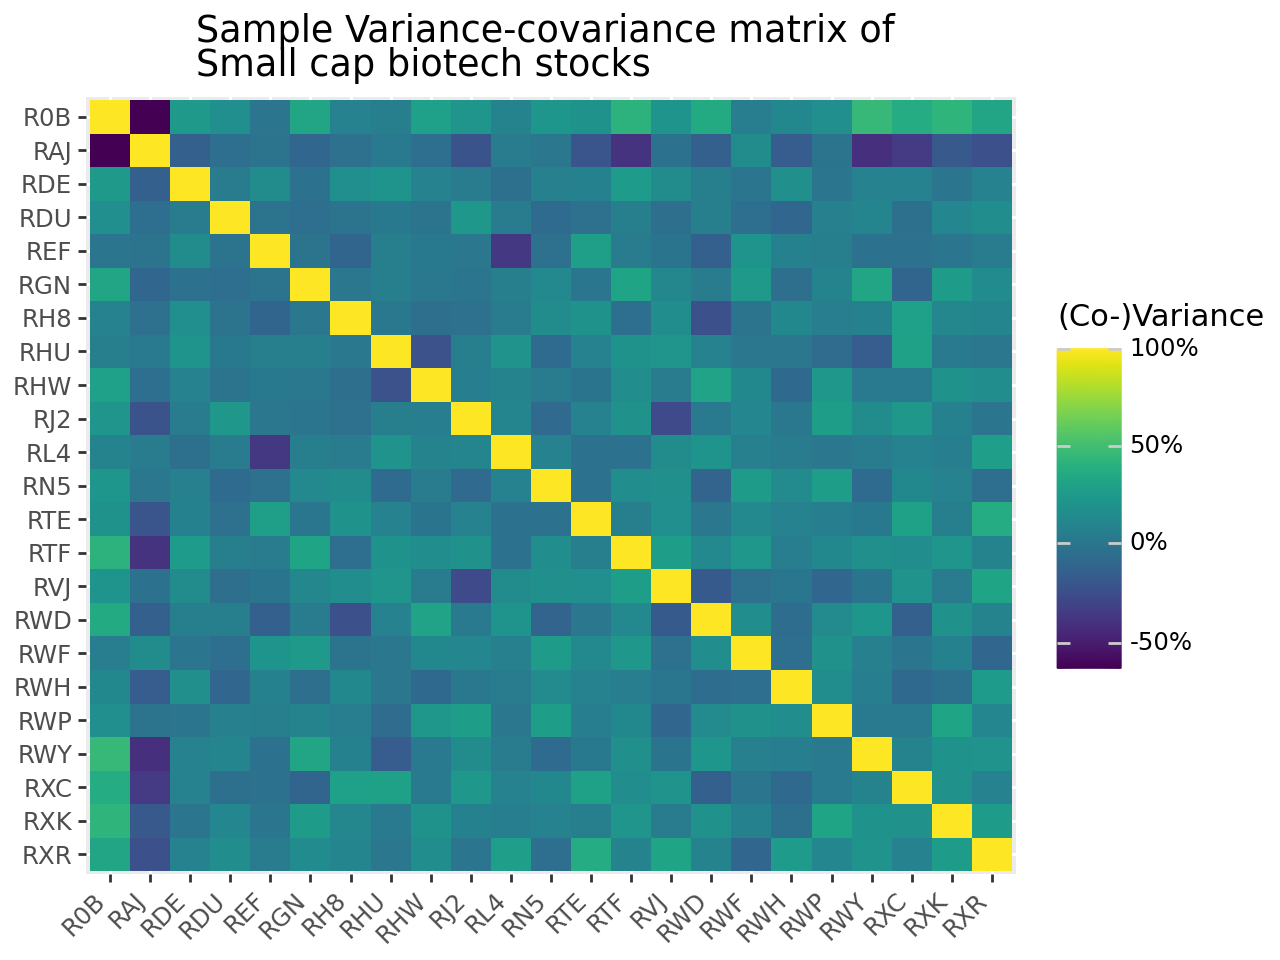

In [282]:


sigma_figure = (
        ggplot(
            sigma_long,
            aes(x="provider", y="symbol_b", fill="value")
        )
        + geom_tile()
        + labs(
    x="", y="", fill="(Co-)Variance",
    title="Sample Variance-covariance matrix of \nSmall cap biotech stocks"
)
        + scale_fill_continuous(labels=percent_format())
        + theme(axis_text_x=element_text(angle=45, hjust=1))
)
sigma_figure.show()

In [283]:
provider_returns_wide = (
    df.query("provider == 'RAJ'")
    .pivot(
        index="period",
        columns="treatment_code",
        values="frac_change"
    )
    .reset_index()
)
provider_returns_wide


treatment_code,period,C_100,C_101,C_110,C_120,C_130,C_140,C_150,C_160,C_170,C_300,C_301,C_320,C_330,C_340,C_400,C_410,C_430,C_502
0,2019-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-02-01,0.006162,0.028679,0.017853,0.025427,0.039430,-0.004950,-0.111111,NaN,NaN,-0.022707,-0.249624,0.008115,NaN,0.091603,0.208738,-0.004454,0.480000,-0.024053
2,2019-03-01,0.008646,0.025594,0.032575,0.004262,0.090265,0.072637,-0.375000,NaN,NaN,-0.024164,0.157315,0.086068,NaN,0.078671,0.000000,0.096197,-0.081081,0.053604
3,2019-04-01,0.012500,0.021390,0.065319,0.049769,0.074617,-0.007421,-0.400000,NaN,NaN,0.161905,0.110823,0.040479,NaN,0.029173,-0.028112,0.022449,-0.029412,0.029825
4,2019-05-01,0.066314,0.174520,0.079727,0.004410,0.122099,0.067290,0.333333,NaN,NaN,0.085246,-0.060016,0.181370,NaN,0.099213,0.314050,0.087824,0.060606,0.052811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,2025-04-01,0.009628,-0.020139,-0.021930,0.001099,0.004003,0.046193,-0.034091,-0.012484,-0.5,0.057881,0.013059,-0.036562,-0.006744,-0.044503,-0.025475,0.099162,0.023653,0.008528
76,2025-05-01,0.033034,0.004524,0.026308,-0.039295,-0.031970,0.033921,0.094118,0.008113,-1.0,0.006734,0.018651,0.019826,0.013651,0.000692,0.034965,-0.032836,0.015404,0.014816
77,2025-06-01,-0.024505,-0.015859,-0.005928,-0.006195,-0.025313,0.000733,0.032258,0.056148,NaN,0.013378,-0.027194,-0.076387,-0.010118,-0.074194,0.004505,0.003429,0.001264,-0.027684
78,2025-07-01,0.045624,0.020889,-0.005798,-0.037526,0.003304,0.048535,-0.041667,0.033847,-1.0,0.031766,0.011809,-0.018497,0.058523,-0.055002,-0.024984,0.005810,-0.041667,0.005170


In [284]:
provider_sigma = (
    provider_returns_wide
    .drop(columns=["period"])
    .cov()
)
provider_sigma

treatment_code,C_100,C_101,C_110,C_120,C_130,C_140,C_150,C_160,C_170,C_300,C_301,C_320,C_330,C_340,C_400,C_410,C_430,C_502
treatment_code,,,,,,,,,,,,,,,,,,
C_100,0.017659,0.011547,0.008793,0.010740,0.009643,0.015474,0.021306,-0.000626,0.007662,0.005267,0.022549,0.010658,0.007091,0.009835,0.085662,0.020327,0.040005,0.025196
C_101,0.011547,0.009835,0.006449,0.007874,0.007968,0.012105,0.017471,0.000274,0.003389,0.003336,0.016620,0.008169,0.003793,0.008091,0.066281,0.016465,0.029440,0.019433
C_110,0.008793,0.006449,0.006025,0.005622,0.006052,0.009369,0.015316,0.000152,0.001001,0.002720,0.012550,0.006280,0.002757,0.006311,0.051035,0.012300,0.023192,0.014687
C_120,0.010740,0.007874,0.005622,0.011493,0.006423,0.009222,0.015370,-0.000064,0.003320,0.001384,0.015732,0.007104,0.006820,0.006692,0.055877,0.015744,0.026246,0.016758
C_130,0.009643,0.007968,0.006052,0.006423,0.009933,0.012281,0.020489,0.000784,0.001598,0.002305,0.015865,0.008301,0.001782,0.007248,0.066894,0.015612,0.030981,0.018973
C_140,0.015474,0.012105,0.009369,0.009222,0.012281,0.021165,0.031784,0.000252,0.000332,0.002326,0.025313,0.012240,0.000923,0.011767,0.105985,0.023941,0.047715,0.029518
C_150,0.021306,0.017471,0.015316,0.015370,0.020489,0.031784,0.127551,0.001499,0.002448,0.002010,0.038876,0.018093,0.000745,0.020018,0.169241,0.039355,0.082396,0.045557
C_160,-0.000626,0.000274,0.000152,-0.000064,0.000784,0.000252,0.001499,0.003015,-0.000609,-0.000965,0.000377,0.000254,0.001351,0.001372,0.001502,0.002162,0.001788,0.000973
C_170,0.007662,0.003389,0.001001,0.003320,0.001598,0.000332,0.002448,-0.000609,0.124413,0.000171,0.008230,0.004328,0.011602,0.005283,0.004710,0.006463,0.009507,0.004703


In [285]:
from plotnine import *
from mizani.formatters import percent_format

provider_sigma_long = (provider_sigma
.reset_index()
.melt(
    id_vars="treatment_code",
    var_name="symbol_b",
    value_name="value"
)
)
provider_sigma_long["symbol_b"] = pd.Categorical(
    provider_sigma_long["symbol_b"],
    categories=provider_sigma_long["symbol_b"].unique()[::-1],
    ordered=True
)
provider_sigma_long


,treatment_code,symbol_b,value
0,C_100,C_100,0.017659
1,C_101,C_100,0.011547
2,C_110,C_100,0.008793
3,C_120,C_100,0.010740
4,C_130,C_100,0.009643
...,...,...,...
319,C_340,C_502,0.017791
320,C_400,C_502,0.163361
321,C_410,C_502,0.037858
322,C_430,C_502,0.073046


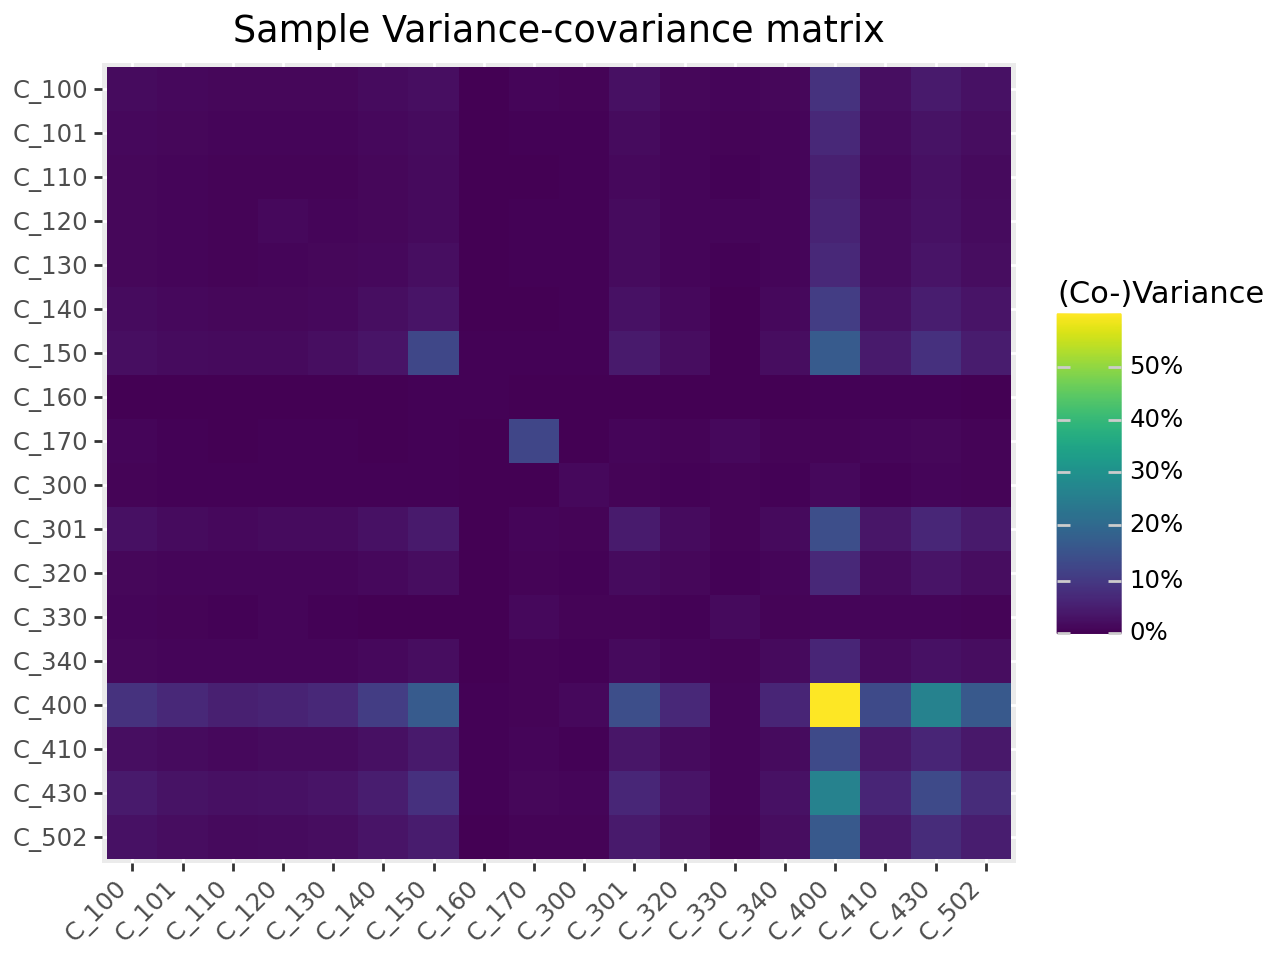

In [286]:

provider_sigma_figure = (
        ggplot(
            provider_sigma_long,
            aes(x="treatment_code", y="symbol_b", fill="value")
        )
        + geom_tile()
        + labs(
    x="", y="", fill="(Co-)Variance",
    title="Sample Variance-covariance matrix"
)
        + scale_fill_continuous(labels=percent_format())
        + theme(axis_text_x=element_text(angle=45, hjust=1))
)
provider_sigma_figure.show()